<a href="https://colab.research.google.com/github/SofyaBekker/DataAnalysisPets/blob/main/diamomds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Мини-проект: датасет diamonds**

Рассмотрим датаест diamonds из seaborn. Проведем EDA и построем простую модель (линейная регрессия) для прогнозирования данных цены бриллианта

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

diamonds = sns.load_dataset('diamonds')

print("Первые 5 строк")
print(diamonds.head())
print('-' * 50)
print("Информация о датасете")
print(diamonds.info())
print('-' * 50)
print("Описательные статистики")
print(diamonds.describe())
print('-' * 50)
print(diamonds.describe(include=['object', 'category']))

Первые 5 строк
   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
--------------------------------------------------
Информация о датасете
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-nu

In [2]:
print("Проверка на пропуски")
print(diamonds.isnull().sum())

Проверка на пропуски
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


Исходя из полученного выше:
 - признаки: караты (вес камня), глубина, размер верхней грани бриллианта, размер в трех измерения, огранка, цвет и частота камня;
 - в датасете отсутствуют пропуски;
 - датасет содержит три столбца с категориальными переменными;
 - наиболее часто встречающимеся являются: огранка Ideal, цвет G - почти бесцветный белый, чистота SI1 - заметные включения, легко различимые при 10 кратном увеличении


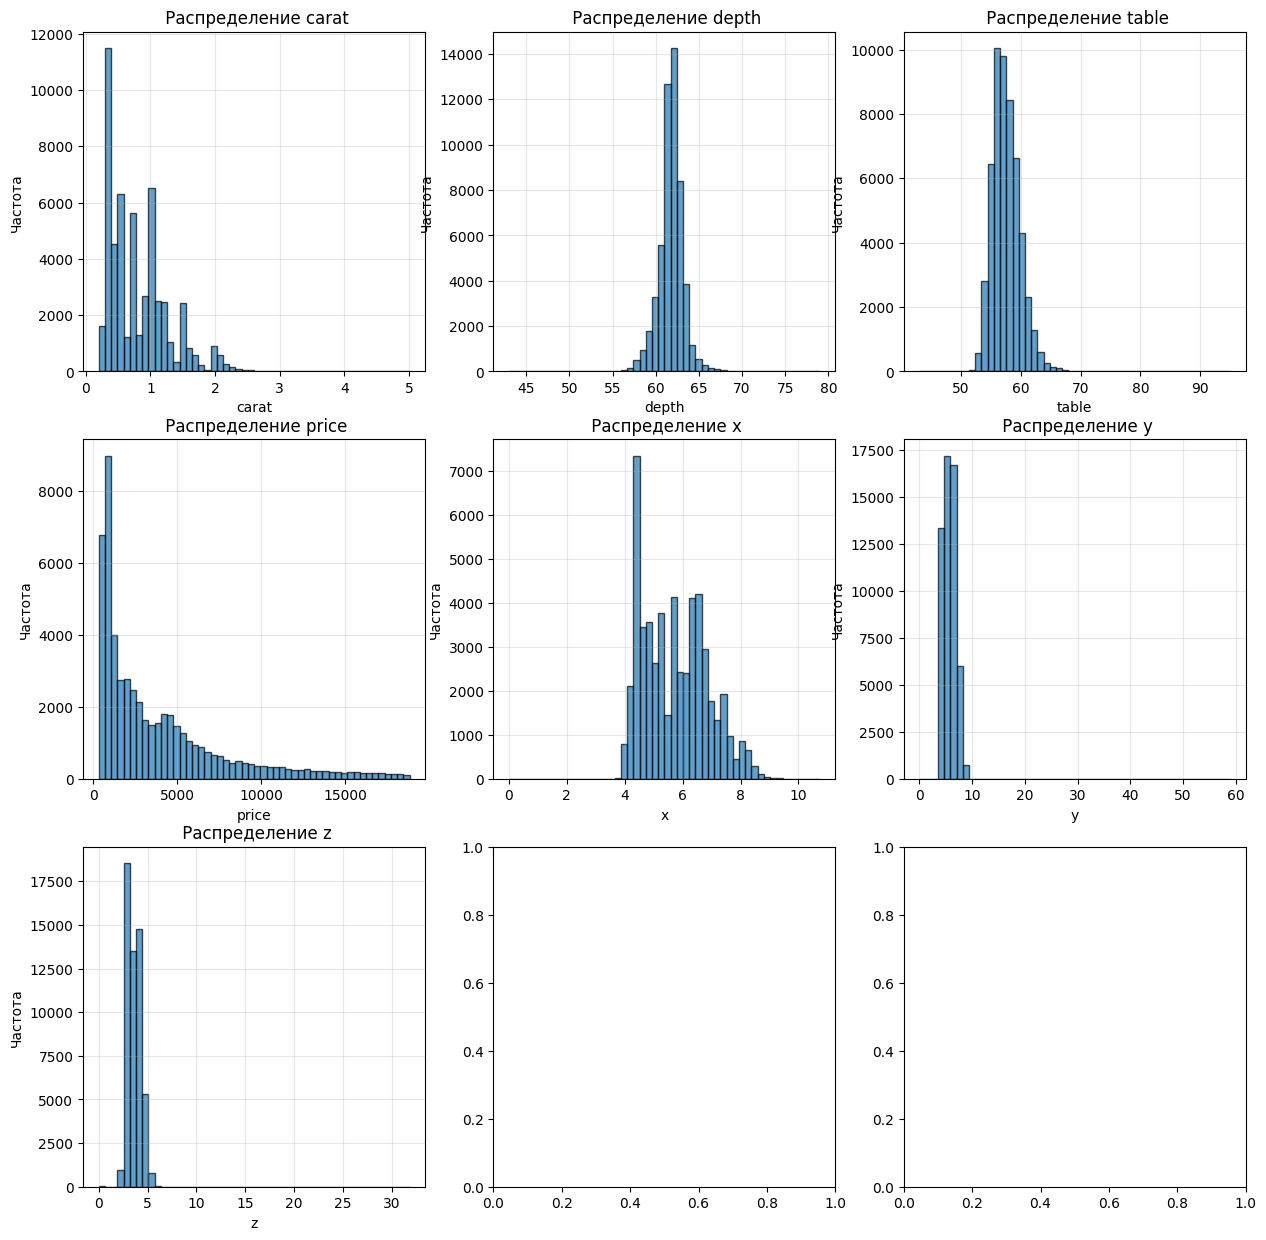

In [5]:
# распределения числовых признаков
numeric_cols = diamonds.select_dtypes(include=[np.number]).columns

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
  axes[i].hist(diamonds[col], bins=50, edgecolor='black', alpha=0.7)
  axes[i].set_title(f' Распределение {col}')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Частота')
  axes[i].grid(True, alpha=0.3)


plt.show()

In [6]:
# коэффициент ассиметрии

from scipy.stats import skew

print("Коэффициент асимметрии (skewness):")
print("  > 1 — сильная правосторонняя асимметрия")
print("  < -1 — сильная левосторонняя асимметрия")
print("  между -0.5 и 0.5 — примерно симметрично")

for col in numeric_cols:
    skew_val = skew(diamonds[col])
    print(f"{col:10}: {skew_val:.3f}")

Коэффициент асимметрии (skewness):
  > 1 — сильная правосторонняя асимметрия
  < -1 — сильная левосторонняя асимметрия
  между -0.5 и 0.5 — примерно симметрично
carat     : 1.117
depth     : -0.082
table     : 0.797
price     : 1.618
x         : 0.379
y         : 2.434
z         : 1.522


- Depth и table имеют распределение, приближенное к нормальному.
- Price и carat имеют сильно скошенное вправо распределение
- y и z также имеют выраженную правостороннюю асимметрию

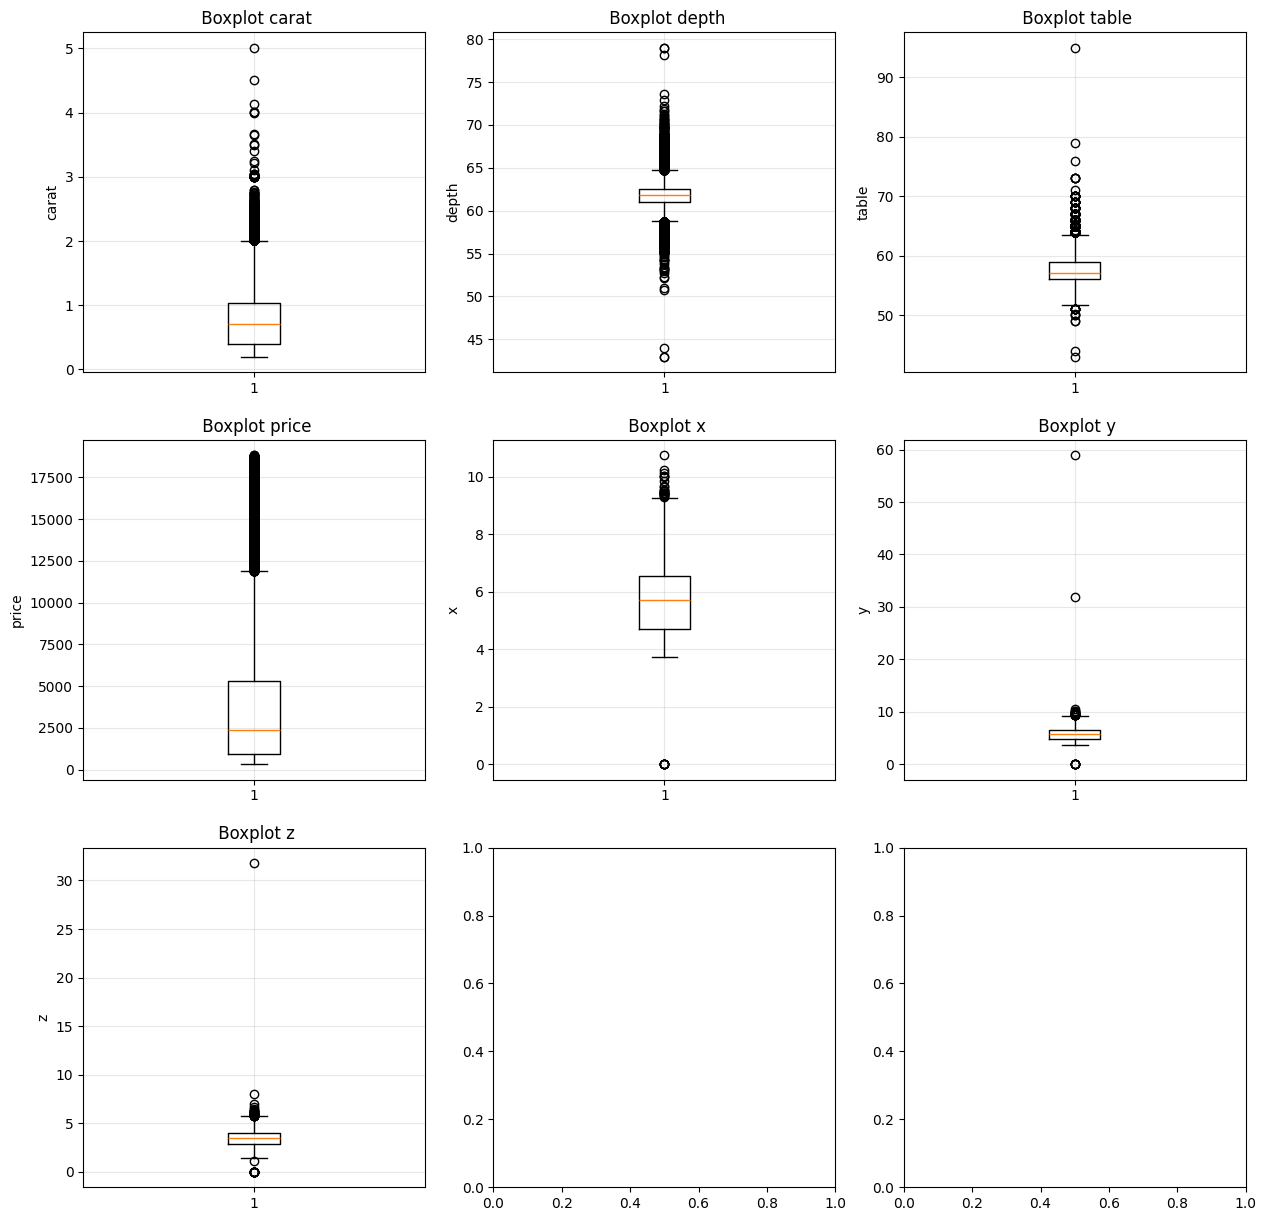

In [8]:
# boxplot для числовых признаков
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
  axes[i].boxplot(diamonds[col])
  axes[i].set_title(f' Boxplot {col}')
  axes[i].set_ylabel(col)
  axes[i].grid(True, alpha=0.3)

plt.show()

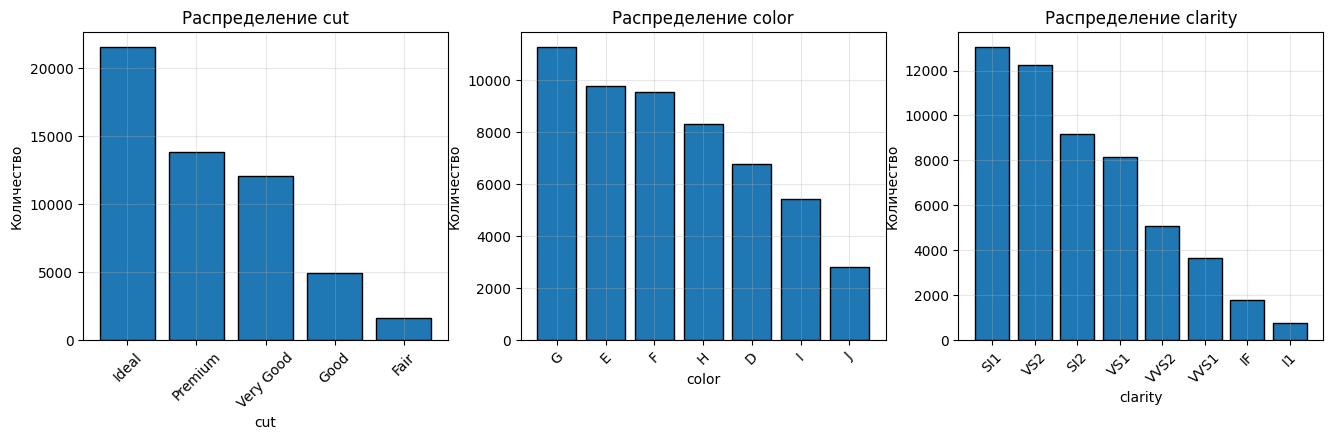

In [9]:
# гистограмма категориальных признаков
categ_cols = diamonds.select_dtypes(include=['object', 'category']).columns

fig, axes =  plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(categ_cols):
  counts = diamonds[col].value_counts()
  axes[i].bar(counts.index, counts.values, edgecolor='black')
  axes[i].set_title(f'Распределение {col}')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Количество')
  axes[i].tick_params(axis='x', rotation=45)
  axes[i].grid(True, alpha=0.3)

plt.show()

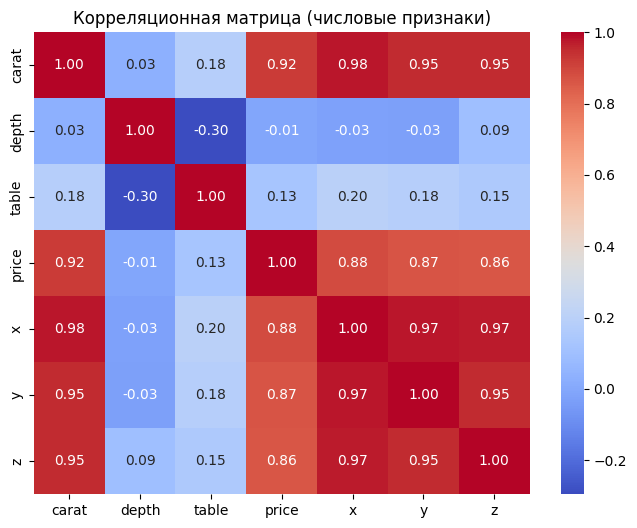

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(diamonds[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляционная матрица (числовые признаки)')
plt.show()

Из корреляционной матрицы видно, чо цена сильнее всего коррелирует с весом и  размерами, что логично, поскольку чем выше вес бриллианта тем больше его стоимость

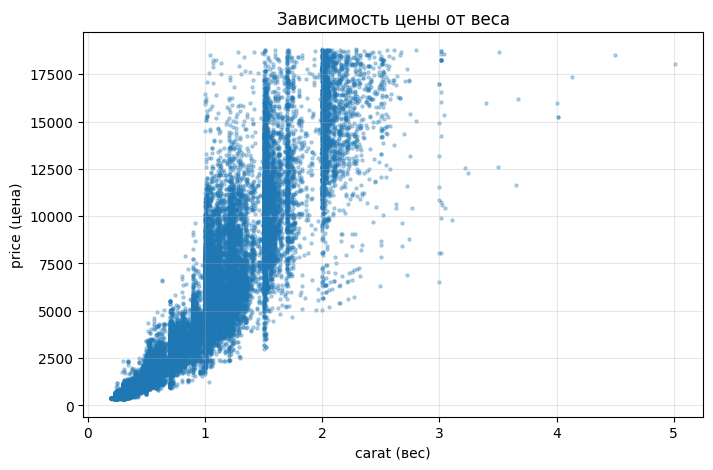

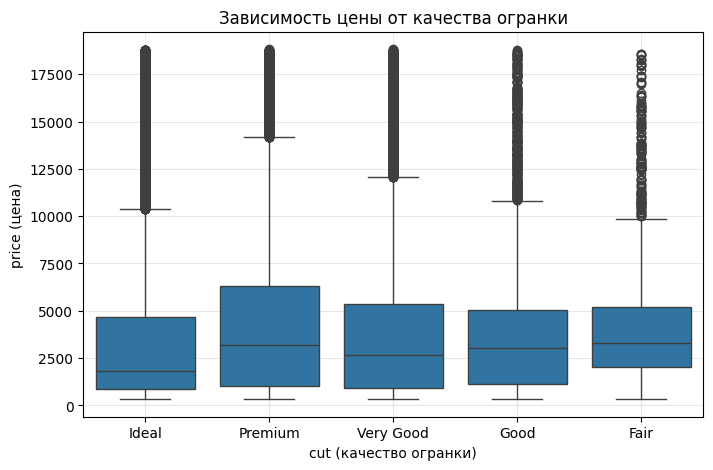

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(diamonds['carat'], diamonds['price'], alpha=0.3, s=5)
plt.xlabel('carat (вес)')
plt.ylabel('price (цена)')
plt.title('Зависимость цены от веса')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=diamonds, x='cut', y='price')
plt.xlabel('cut (качество огранки)')
plt.ylabel('price (цена)')
plt.title('Зависимость цены от качества огранки')
plt.grid(True, alpha=0.3)
plt.show()

- Присутствует большое распыление данных, потому что бриллианты с одним весом могут сильно разно стоить (предполагаю, что из-за огранки, цвета и чистоты камня)
- Премиум огранка стоит больше всех, но в среднем встречаются дорогие камни разных типов огранки

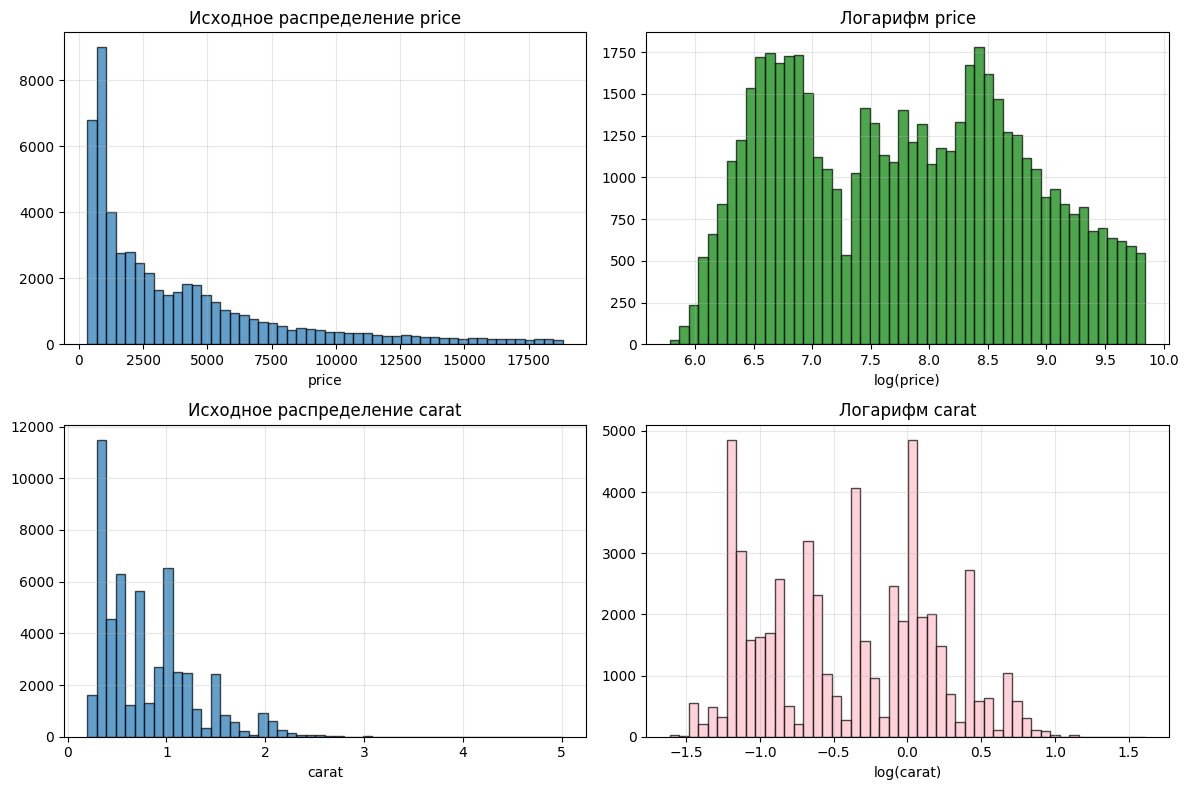

In [12]:
# Из-за сильной правосторонней ассиметрии прологарифмируем признаки price и carat
diamonds['log_price'] = np.log(diamonds['price'])
diamonds['log_carat'] = np.log(diamonds['carat'])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# price
axes[0, 0].hist(diamonds['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Исходное распределение price')
axes[0, 0].set_xlabel('price')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(diamonds['log_price'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_title('Логарифм price')
axes[0, 1].set_xlabel('log(price)')
axes[0, 1].grid(True, alpha=0.3)

# carat
axes[1, 0].hist(diamonds['carat'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Исходное распределение carat')
axes[1, 0].set_xlabel('carat')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(diamonds['log_carat'], bins=50, edgecolor='black', alpha=0.7, color='pink')
axes[1, 1].set_title('Логарифм carat')
axes[1, 1].set_xlabel('log(carat)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

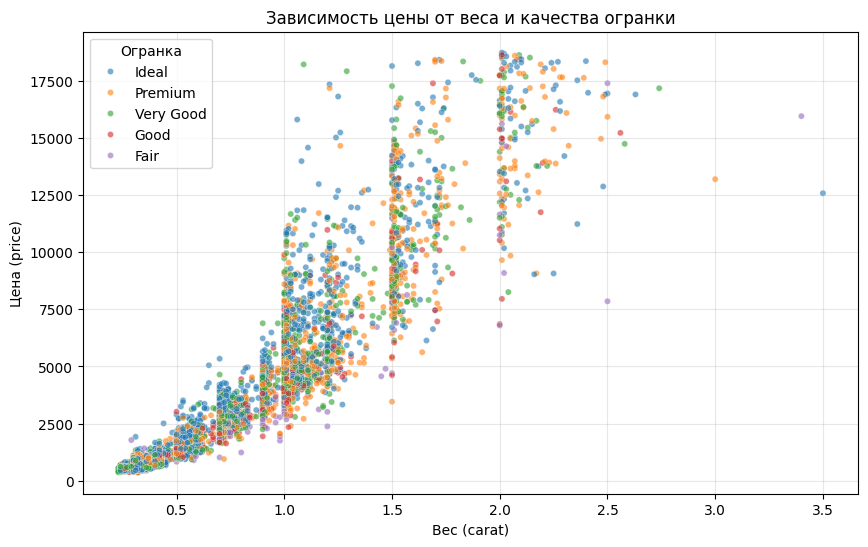

In [13]:
# scatterplot price vs carat
plt.figure(figsize=(10, 6))
sns.scatterplot(data=diamonds.sample(5000), # берём подвыборку, чтобы не было слишком плотно
                x='carat', y='price', hue='cut', alpha=0.6, s=20)
plt.xlabel('Вес (carat)')
plt.ylabel('Цена (price)')
plt.title('Зависимость цены от веса и качества огранки')
plt.legend(title='Огранка')
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_2992/3802085480.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=diamonds, x='cut', y='price', palette='Set2')


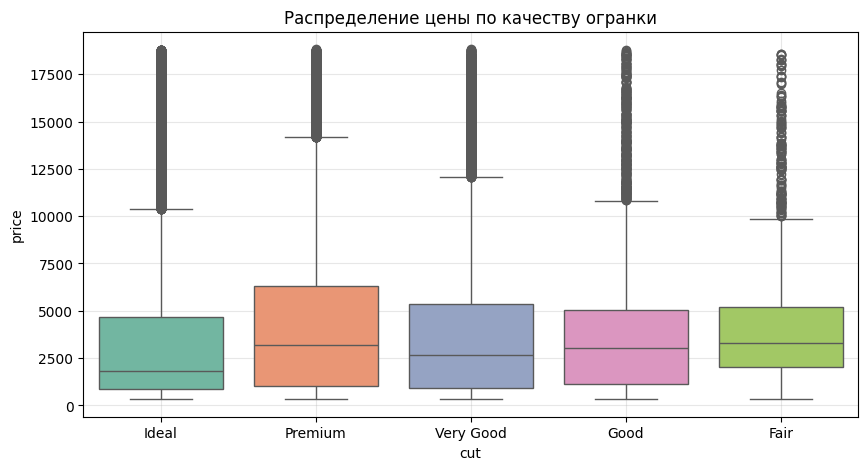

In [14]:
# boxplot price vs cut
plt.figure(figsize=(10, 5))
sns.boxplot(data=diamonds, x='cut', y='price', palette='Set2')
plt.xlabel('cut')
plt.ylabel('price')
plt.title('Распределение цены по качеству огранки')
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_2992/3312530471.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=diamonds, x='color', y='price', palette='Set3')


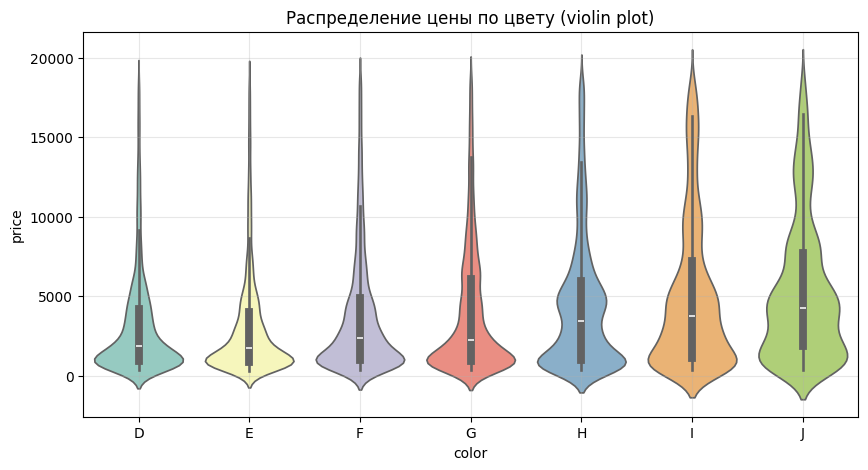

In [15]:
plt.figure(figsize=(10, 5))
sns.violinplot(data=diamonds, x='color', y='price', palette='Set3')
plt.xlabel('color')
plt.ylabel('price')
plt.title('Распределение цены по цвету (violin plot)')
plt.grid(True, alpha=0.3)
plt.show()

- Самую высоку цену при одинаковом весе обычно дает огранка либо Premium, либо Ideal, у крупных камней огранка может быть хуже. Premium продаётся по более высокой средней цене, чем Ideal, потому что Premium чаще встречается у крупных камней, а Ideal — у мелких.
- В основном график выглядит  как плотные полосы на круглом весе, что не удивительно, потому что люди любят круглые числа и поэтому огранщики стараются делать такие камни
- Если смотреть по величине разброса выбросов, больше всего их в fair, но в группе Ideal визуально больше значений
- D, E -	Бесцветные, идеальные.	Очень дорогие (но их мало)
  
  G, H -	Почти бесцветные.	Средняя цена (их много)
  
  I, J -	Слегка желтоватые.	Могут быть дёшевыми, но среди них есть очень крупные камни, которые тянут цену вверх

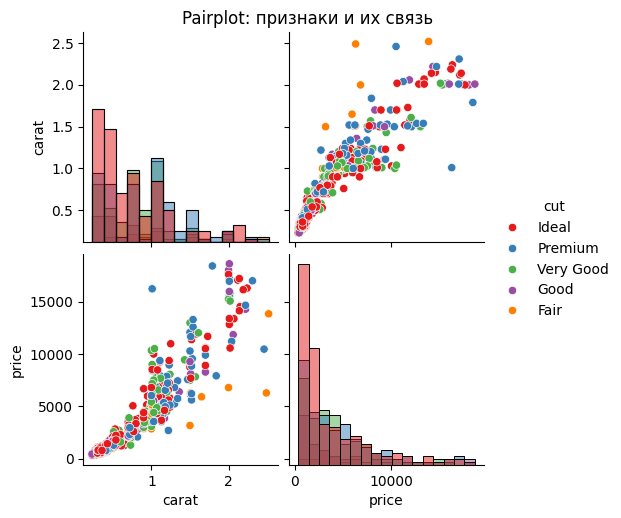

In [16]:
subset = diamonds[['carat', 'price', 'cut', 'color', 'clarity']].sample(500)

sns.pairplot(subset, hue='cut', palette='Set1', diag_kind='hist')
plt.suptitle('Pairplot: признаки и их связь', y=1.02)
plt.show()

In [17]:
# построение простой модели - линейной регрессии
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# создаем фиктивные переменные
diamonds_dummies = pd.get_dummies(diamonds, columns=['cut', 'color', 'clarity'],
                                  drop_first=True)

# выбираем признаки для модели
features = ['log_carat'] + [col for col in diamonds_dummies.columns if col.startswith(('cut_', 'color_', 'clarity_'))]
X = diamonds_dummies[features]
y = diamonds_dummies['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('Оценка модели')
print(f"RMSE (в логарифмической шкале): {rmse:.4f}")
print(f"Ошибка предсказания: {np.exp(rmse):.3f}")
print(f"R²: {r2:.4f}")

Оценка модели
RMSE (в логарифмической шкале): 0.1351
Ошибка предсказания: 1.145
R²: 0.9821


In [18]:
# при интерпретации не забывать,
# что фейковые переменные сравниваются с опорной и коэффициенты идут в сравнении с ней
print('Интерпретация коэффициентов')
coefs = pd.DataFrame({
    'Признак' : X.columns,
    'Коэффициент' : model.coef_
})

coefs = coefs.sort_values('Коэффициент', ascending=False)

for idx, row in coefs.iterrows():
  impact = np.exp(row['Коэффициент']) - 1
  print(f"{row['Признак']:20} : {row['Коэффициент']:8.4f}")

print("Топ-3 самых сильных драйвера цены:")
print(coefs.head(3).to_string(index=False))

print("Топ-3 самых сильных понижателя цены:")
print(coefs.tail(3).to_string(index=False))

Интерпретация коэффициентов
log_carat            :   1.8854
cut_Premium          :  -0.0216
cut_Very Good        :  -0.0441
color_E              :  -0.0553
cut_Good             :  -0.0808
color_F              :  -0.0947
clarity_VVS1         :  -0.0981
color_G              :  -0.1615
cut_Fair             :  -0.1622
clarity_VVS2         :  -0.1688
color_H              :  -0.2524
clarity_VS1          :  -0.3062
color_I              :  -0.3740
clarity_VS2          :  -0.3754
color_J              :  -0.5123
clarity_SI1          :  -0.5232
clarity_SI2          :  -0.6901
clarity_I1           :  -1.1289
Топ-3 самых сильных драйвера цены:
      Признак  Коэффициент
    log_carat     1.885422
  cut_Premium    -0.021565
cut_Very Good    -0.044103
Топ-3 самых сильных понижателя цены:
    Признак  Коэффициент
clarity_SI1    -0.523243
clarity_SI2    -0.690142
 clarity_I1    -1.128914


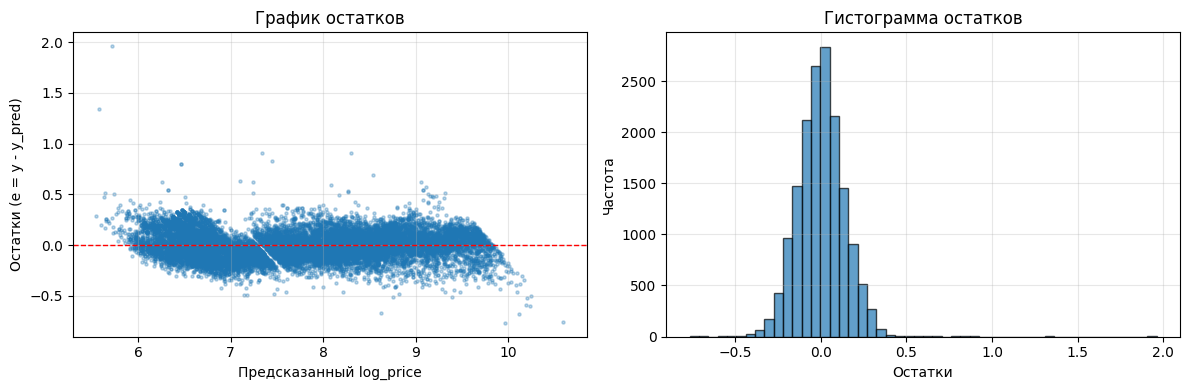

Самые большие ошибки модели
Предсказания дешевле, чем есть на самом деле
       log_carat  actual_price  predicted_price        error
27673   0.405465       18691.0     11157.596576  7533.403424
26407   0.000000       15928.0      8566.563867  7361.436133
26491   0.009950       16087.0      9055.091278  7031.908722
27196   0.131028       17499.0     10967.214277  6531.785723
25925   0.009950       15081.0      8728.794543  6352.205457
Пресказания дороже, чем есть на самом деле
       log_carat  actual_price  predicted_price         error
27679   1.255616       18701.0     39915.688282 -21214.688282
25998   1.388791       15223.0     27732.373044 -12509.373044
24328   1.252763       12587.0     24763.116434 -12176.116434
25778   0.947789       14749.0     26613.219016 -11864.219016
21862   1.101940        9925.0     21350.628404 -11425.628404


In [19]:
# анализ остатков
residuals = y_test - y_pred

plt.figure(figsize=(12, 4))

# предсказанные и остатки
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.3, s=5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Предсказанный log_price')
plt.ylabel('Остатки (e = y - y_pred)')
plt.title('График остатков')
plt.grid(True, alpha=0.3)

# гистограмма остатков
plt.subplot(1, 2, 2)
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Остатки')
plt.ylabel('Частота')
plt.title('Гистограмма остатков')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Самые большие ошибки модели")

test_results = X_test.copy()
test_results['actual_price'] = np.exp(y_test)
test_results['predicted_price'] = np.exp(y_pred)
test_results['error'] = test_results['actual_price'] - test_results['predicted_price']

print('Предсказания дешевле, чем есть на самом деле')
print(test_results.nlargest(5, 'error')[['log_carat', 'actual_price', 'predicted_price', 'error']])
print('Пресказания дороже, чем есть на самом деле')
print(test_results.nsmallest(5, 'error')[['log_carat', 'actual_price', 'predicted_price', 'error']])

- Поскольку мы предсказывали log(price), чтобы понять ошибку в долларах, нужно возвести экспоненту. Предсказания в среднем отклоняются от реальной цены всего на ~14.5%.

- В средней модель имеет нормально распределенные остатки с нулевым матожиданием и среднеквадратичным отклонением 0.14

- Караты больше всего влияют на цену (не удивительно)

- Огранка Premium стоит на ~2.1% дешевле, чем Fair;  Very good стоит на ~4.4% дешевле, чем Fair

- Цвет и чистота сильно влияют на цену:

    clarity_I1 — снижает цену на ~68% по сравнению с лучшей чистотой.

    color_J — снижает цену на ~40% по сравнению с лучшим цветом.

- Модель недооценивает дорогие и переоценивает дешевые камни. Это связано с тем, что модель не учитывает комбинацию признаков. Сочетание чистоты и веса или цвета и веса дают разный эффект для цен (например, большой камень редкого цвета будет стоить очень дорого при худшей огранке). Это можно решить, если использовать в модели взаимодействие признаков, например, log_carat * clarity